# 03 — Event Study Methodology
This notebook defines and tests the event study framework applied throughout the project.
Covers: abnormal return calculation, event window definition, cumulative abnormal returns (CARs),
and benchmark period selection. Methodology tested on a single event before full application.
Last updated: March 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load asset price data
prices = pd.read_csv('../data/processed/asset_prices_final.csv',
                     index_col='Date', parse_dates=True)

# Load event list
events = pd.read_csv('../data/processed/event_list_with_severity.csv',
                     parse_dates=['Date'])

print("Asset prices shape:", prices.shape)
print("Events shape:", events.shape)
print("\nColumns:", prices.columns.tolist())

C:\Users\tomsu\Anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Asset prices shape: (6596, 22)
Events shape: (87, 10)

Columns: ['Bitcoin', 'Oil_Brent', 'Oil_WTI', 'DXY', 'EEM', 'Gold', 'Copper', 'USDJPY', 'SPY', 'USDCNY', 'USDTRY', 'MOVE', 'Nikkei225', 'EuroStoxx50', 'VIX', 'US2YR', 'US10YR', 'US30YR', 'TIPS5YR', 'HY_Spread', 'IG_Spread', 'EM_Spread']


In [2]:
# ============================================================
# SERIES CLASSIFICATION — RETURNS VS FIRST DIFFERENCES
# ============================================================

# Price series — calculate percentage returns (daily % change)
# These are asset prices where % move is the natural unit of measurement
price_series = [
    'SPY', 'EEM', 'EuroStoxx50', 'Nikkei225',  # Equities
    'Gold', 'Oil_WTI', 'Oil_Brent', 'Copper',   # Commodities
    'DXY', 'USDJPY', 'USDCNY', 'USDTRY',        # FX
    'Bitcoin',                                    # Crypto
    'MOVE', 'VIX'                                 # Volatility — level changes make more sense
                                                  # but kept as % for consistency
]

# Level series — calculate first differences (daily absolute change)
# These are rates and spreads where absolute basis point moves are the natural unit
level_series = [
    'US2YR', 'US10YR', 'US30YR', 'TIPS5YR',     # Rates — basis point changes
    'HY_Spread', 'IG_Spread', 'EM_Spread'         # Credit spreads — basis point changes
]

print("Price series (percentage returns):", len(price_series))
print(price_series)
print("\nLevel series (first differences — basis points):", len(level_series))
print(level_series)
print("\nTotal series:", len(price_series) + len(level_series))

Price series (percentage returns): 15
['SPY', 'EEM', 'EuroStoxx50', 'Nikkei225', 'Gold', 'Oil_WTI', 'Oil_Brent', 'Copper', 'DXY', 'USDJPY', 'USDCNY', 'USDTRY', 'Bitcoin', 'MOVE', 'VIX']

Level series (first differences — basis points): 7
['US2YR', 'US10YR', 'US30YR', 'TIPS5YR', 'HY_Spread', 'IG_Spread', 'EM_Spread']

Total series: 22


In [3]:
# Move VIX and MOVE to level series
price_series = [
    'SPY', 'EEM', 'EuroStoxx50', 'Nikkei225',
    'Gold', 'Oil_WTI', 'Oil_Brent', 'Copper',
    'DXY', 'USDJPY', 'USDCNY', 'USDTRY',
    'Bitcoin'
]

level_series = [
    'US2YR', 'US10YR', 'US30YR', 'TIPS5YR',
    'HY_Spread', 'IG_Spread', 'EM_Spread',
    'VIX', 'MOVE'
]

print("Price series (percentage returns):", len(price_series))
print("Level series (first differences):", len(level_series))
print("Total:", len(price_series) + len(level_series))

Price series (percentage returns): 13
Level series (first differences): 9
Total: 22


In [4]:
# ============================================================
# CHUNK 2 — CALCULATE RETURNS AND FIRST DIFFERENCES
# ============================================================

# Percentage returns for price series
returns = pd.DataFrame(index=prices.index)

for col in price_series:
    returns[col] = prices[col].pct_change() * 100  # expressed as percentage

# First differences for level series
for col in level_series:
    returns[col] = prices[col].diff()  # expressed in basis points / index points

# Drop first row — NaN from pct_change and diff
returns = returns.dropna(how='all')

# Quick diagnostics
print("Returns dataframe shape:", returns.shape)
print("\nDate range:", returns.index[0], "to", returns.index[-1])
print("\nSample — first few rows of key series:")
print(returns[['SPY', 'Gold', 'US10YR', 'VIX']].head(10))
print("\nNaN counts:")
print(returns.isnull().sum())

Returns dataframe shape: (6595, 22)

Date range: 2000-01-04 00:00:00 to 2026-03-25 00:00:00

Sample — first few rows of key series:
                 SPY  Gold  US10YR   VIX
Date                                    
2000-01-04 -3.910645   NaN   -0.09  2.80
2000-01-05  0.178894   NaN    0.13 -0.60
2000-01-06 -1.607098   NaN   -0.05 -0.68
2000-01-07  5.807657   NaN   -0.05 -4.01
2000-01-10  0.343058   NaN    0.05 -0.01
2000-01-11 -1.196599   NaN    0.10  0.79
2000-01-12 -0.994795   NaN    0.05  0.34
2000-01-13  1.354242   NaN   -0.09 -1.13
2000-01-14  1.357798   NaN    0.06 -2.05
2000-01-18 -0.786799   NaN    0.06  1.84

NaN counts:
SPY               0
EEM             822
EuroStoxx50    1819
Nikkei225         1
Gold           1226
Oil_WTI         162
Oil_Brent      1902
Copper          167
DXY               0
USDJPY            0
USDCNY          372
USDTRY         1256
Bitcoin        3699
US2YR             0
US10YR            0
US30YR            0
TIPS5YR         752
HY_Spread         0
IG_

In [5]:
# ============================================================
# CHUNK 3 — ESTIMATION WINDOW FUNCTION
# ============================================================

def get_estimation_window(event_date, returns, estimation_days=252, buffer_days=30):
    """
    Extract estimation window for a given event.
    
    Parameters:
    - event_date: date of the event
    - returns: full returns dataframe
    - estimation_days: number of trading days in estimation window (default 252 = 1 year)
    - buffer_days: trading days between estimation window end and event date (default 30)
    
    Returns:
    - estimation window dataframe
    - mean returns for each series
    - standard deviation of returns for each series
    """
    
    # Find position of event date in index
    # Use the nearest available trading day if exact date not in index
    available_dates = returns.index
    event_idx = available_dates.searchsorted(event_date)
    
    # Apply buffer — go back buffer_days before event
    buffer_end = event_idx - buffer_days
    
    # Apply estimation window
    buffer_start = buffer_end - estimation_days
    
    # Check we have enough data
    if buffer_start < 0:
        return None, None, None
    
    # Extract estimation window
    est_window = returns.iloc[buffer_start:buffer_end]
    
    # Calculate mean and standard deviation for each series
    est_mean = est_window.mean()
    est_std = est_window.std()
    
    # Replace zero std with NaN to avoid division by zero
    est_std = est_std.replace(0, np.nan)
    
    return est_window, est_mean, est_std

# Test on Russia-Ukraine invasion
test_date = pd.Timestamp('2022-02-24')
est_window, est_mean, est_std = get_estimation_window(test_date, returns)

print("Estimation window for Russia-Ukraine invasion:")
print("Window shape:", est_window.shape)
print("Window date range:", est_window.index[0], "to", est_window.index[-1])
print("\nEstimated mean daily returns (selected series):")
print(est_mean[['SPY', 'Gold', 'US10YR', 'VIX', 'HY_Spread']].round(4))
print("\nEstimated standard deviations (selected series):")
print(est_std[['SPY', 'Gold', 'US10YR', 'VIX', 'HY_Spread']].round(4))

Estimation window for Russia-Ukraine invasion:
Window shape: (252, 22)
Window date range: 2021-01-12 00:00:00 to 2022-01-10 00:00:00

Estimated mean daily returns (selected series):
SPY          0.0905
Gold        -0.0076
US10YR       0.0025
VIX         -0.0186
HY_Spread   -0.0023
dtype: float64

Estimated standard deviations (selected series):
SPY          0.8162
Gold         0.8273
US10YR       0.0430
VIX          2.0851
HY_Spread    0.0581
dtype: float64


In [6]:
# ============================================================
# CHUNK 4 — ABNORMAL RETURN CALCULATION
# ============================================================

def get_event_window(event_date, returns, pre_event=5, post_event=20):
    """
    Extract event window around event date.
    
    Parameters:
    - event_date: date of the event
    - returns: full returns dataframe
    - pre_event: trading days before event (default 5)
    - post_event: trading days after event (default 20)
    
    Returns:
    - event window dataframe with relative day index (-5 to +20)
    """
    available_dates = returns.index
    event_idx = available_dates.searchsorted(event_date)
    
    # Check we have enough data
    if event_idx - pre_event < 0:
        return None
    if event_idx + post_event >= len(available_dates):
        return None
    
    # Extract event window
    window_start = event_idx - pre_event
    window_end = event_idx + post_event + 1
    
    event_window = returns.iloc[window_start:window_end].copy()
    
    # Add relative day index
    event_window.index = range(-pre_event, post_event + 1)
    
    return event_window


def calculate_abnormal_returns(event_date, returns, 
                                estimation_days=252, buffer_days=30,
                                pre_event=5, post_event=20):
    """
    Calculate abnormal returns and standardised abnormal returns
    for a single event across all series.
    
    Returns:
    - AR: abnormal returns (actual minus expected)
    - SAR: standardised abnormal returns (AR divided by estimation window std)
    - CAR: cumulative abnormal returns
    """
    
    # Get estimation window parameters
    est_window, est_mean, est_std = get_estimation_window(
        event_date, returns, estimation_days, buffer_days)
    
    if est_window is None:
        return None, None, None
    
    # Get event window
    event_window = get_event_window(event_date, returns, pre_event, post_event)
    
    if event_window is None:
        return None, None, None
    
    # Calculate abnormal returns — actual minus expected (estimation mean)
    AR = event_window - est_mean
    
    # Calculate standardised abnormal returns — AR divided by estimation std
    SAR = AR / est_std
    
    # Calculate cumulative abnormal returns
    CAR = AR.cumsum()
    
    return AR, SAR, CAR


# Test on Russia-Ukraine invasion
test_date = pd.Timestamp('2022-02-24')
AR, SAR, CAR = calculate_abnormal_returns(test_date, returns)

print("Abnormal returns calculated for Russia-Ukraine invasion")
print("AR shape:", AR.shape)
print("\nAbnormal returns around event (selected series):")
print(AR[['SPY', 'Gold', 'US10YR', 'VIX', 'HY_Spread']].round(4))
print("\nStandardised abnormal returns (selected series):")
print(SAR[['SPY', 'Gold', 'US10YR', 'VIX', 'HY_Spread']].round(4))

Abnormal returns calculated for Russia-Ukraine invasion
AR shape: (26, 22)

Abnormal returns around event (selected series):
       SPY    Gold  US10YR     VIX  HY_Spread
-5  0.0216  1.0360 -0.0225 -1.3914     0.0123
-4 -2.2267  1.3744 -0.0625  3.8386     0.0623
-3 -0.7380 -0.0657 -0.0525 -0.3414     0.0423
-2 -1.1637  0.2165  0.0175  1.0786    -0.0277
-1 -1.8644  0.4583  0.0475  2.2286    -0.0277
0   1.4144 -0.6374 -0.0325 -0.6814     0.2123
1   2.1159 -0.3255  0.0075 -2.7114    -0.3077
2  -0.3464  1.0441 -0.1425  2.5786     0.1523
3  -1.6135  1.8239 -0.1125  3.1886     0.1223
4   1.7491 -1.0330  0.1375 -2.5614    -0.1777
5  -0.5884  0.6029 -0.0025 -0.2414     0.0023
6  -0.9030  1.6005 -0.1225  1.5186     0.1923
7  -3.0384  1.4939  0.0375  4.4886     0.1123
8  -0.8487  2.7435  0.0775 -1.3014     0.0223
9   2.5906 -2.9635  0.0775 -2.6614    -0.0877
10 -0.5421  0.3197  0.0375 -2.2014     0.0623
11 -1.3620 -0.6952  0.0175  0.5386     0.0523
12 -0.8214 -1.4998  0.1375  1.0386     0.1123
1

ValueError: Multi-dimensional indexing (e.g. `obj[:, None]`) is no longer supported. Convert to a numpy array before indexing instead.

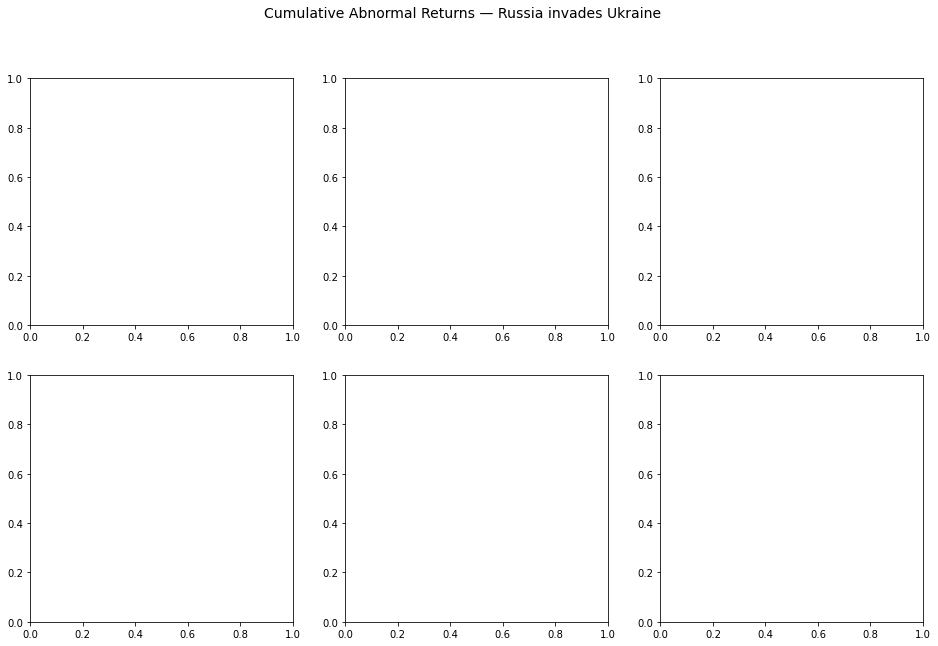

In [7]:
# ============================================================
# CHUNK 5 — CAR PLOT FOR SINGLE EVENT
# ============================================================

def plot_car(event_date, event_name, returns, series_to_plot=None):
    """
    Plot cumulative abnormal returns around a single event.
    """
    AR, SAR, CAR = calculate_abnormal_returns(event_date, returns)
    
    if AR is None:
        print(f"Insufficient data for {event_name}")
        return
    
    if series_to_plot is None:
        series_to_plot = ['SPY', 'Gold', 'US10YR', 'VIX', 'HY_Spread', 'Oil_WTI']
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f'Cumulative Abnormal Returns — {event_name}', fontsize=14)
    axes = axes.flatten()
    
    for i, series in enumerate(series_to_plot):
        ax = axes[i]
        
        if CAR[series].isnull().all():
            ax.set_title(f'{series} — no data')
            continue
        
        # Plot CAR
        ax.plot(CAR.index, CAR[series], linewidth=2, color='steelblue')
        
        # Add event line
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Event date')
        
        # Add zero line
        ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        
        # Shade pre and post event
        ax.axvspan(-5, 0, alpha=0.1, color='orange', label='Pre-event')
        ax.axvspan(0, 20, alpha=0.1, color='blue', label='Post-event')
        
        ax.set_title(series)
        ax.set_xlabel('Trading days relative to event')
        ax.set_ylabel('Cumulative Abnormal Return')
        ax.legend(fontsize=7)
    
    plt.tight_layout()
    plt.savefig(f'../outputs/charts/car_{event_name.replace(" ", "_").replace("/", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Chart saved for {event_name}")

# Test on three events
plot_car(pd.Timestamp('2022-02-24'), 'Russia invades Ukraine', returns)
plot_car(pd.Timestamp('2023-10-07'), 'Hamas attack Gaza', returns)
plot_car(pd.Timestamp('2025-04-02'), 'Liberation Day tariffs', returns)

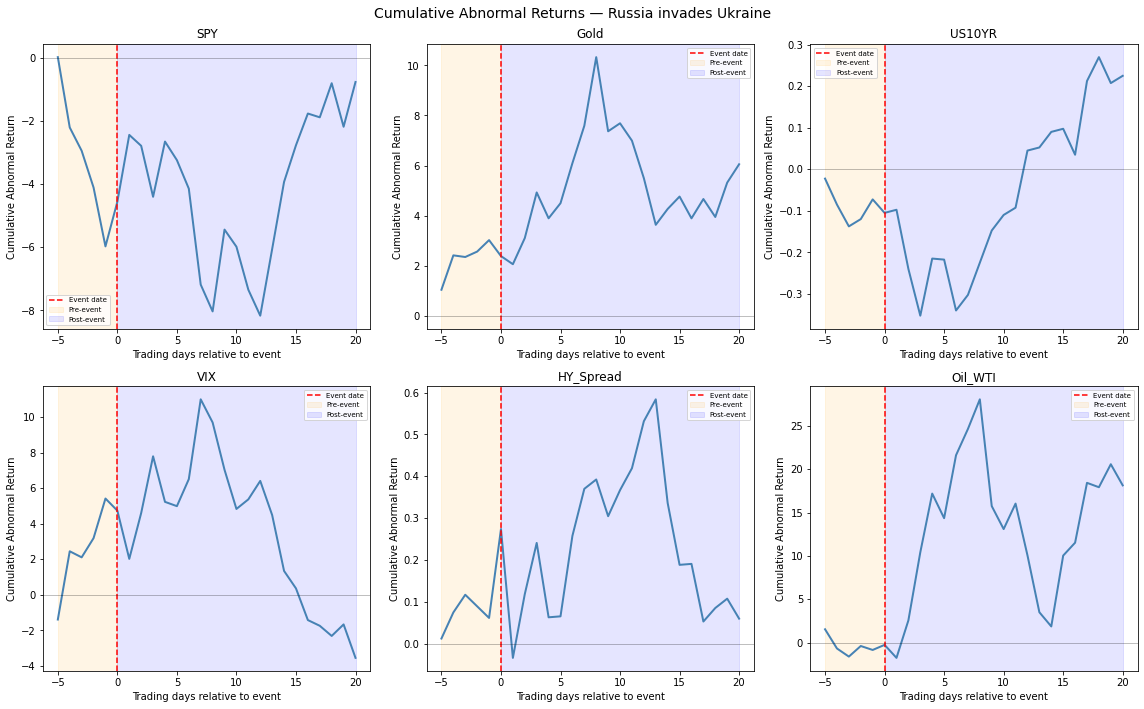

Chart saved for Russia invades Ukraine


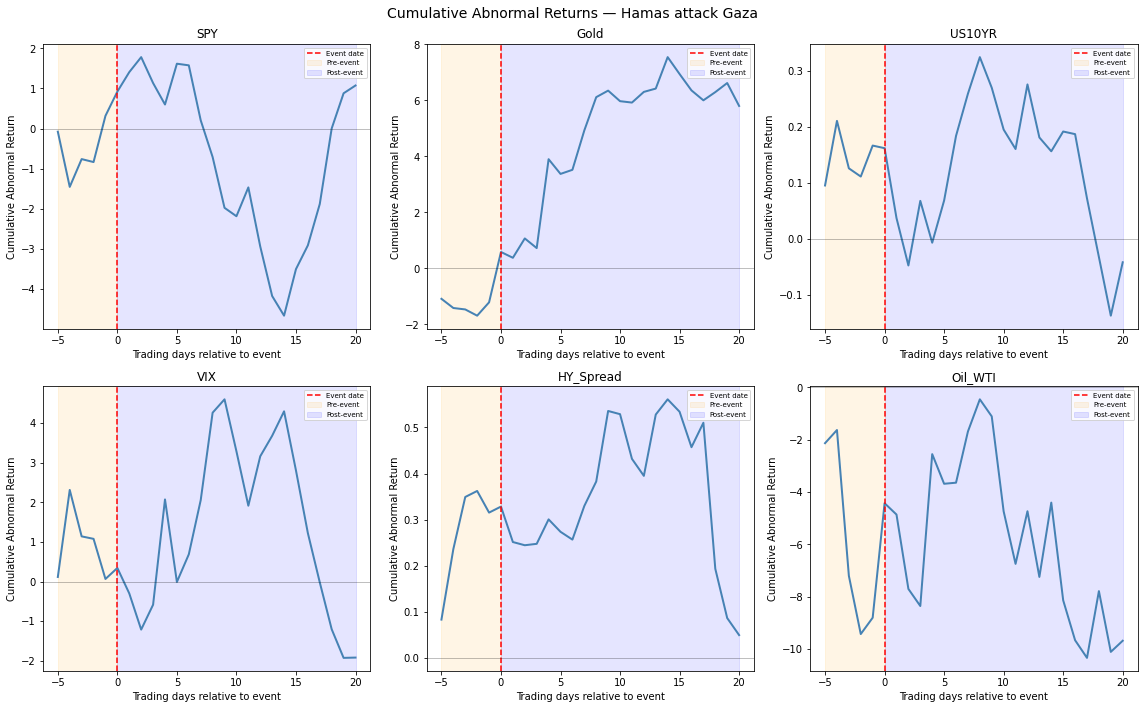

Chart saved for Hamas attack Gaza


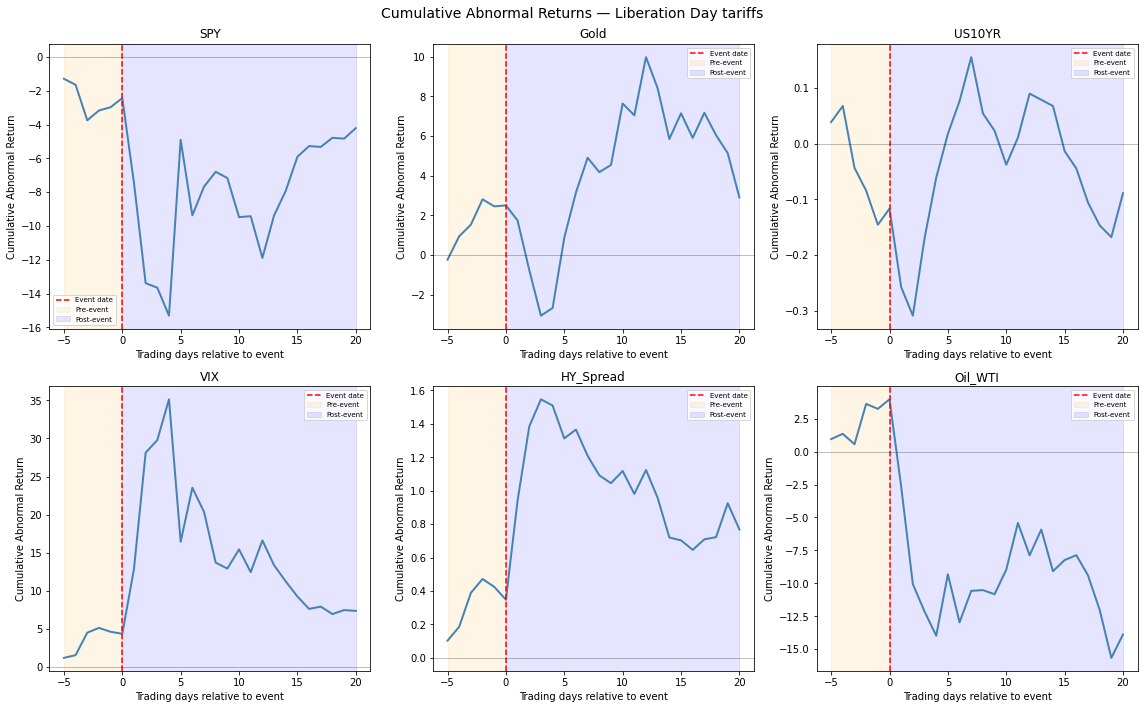

Chart saved for Liberation Day tariffs


In [8]:
def plot_car(event_date, event_name, returns, series_to_plot=None):
    """
    Plot cumulative abnormal returns around a single event.
    """
    AR, SAR, CAR = calculate_abnormal_returns(event_date, returns)
    
    if AR is None:
        print(f"Insufficient data for {event_name}")
        return
    
    if series_to_plot is None:
        series_to_plot = ['SPY', 'Gold', 'US10YR', 'VIX', 'HY_Spread', 'Oil_WTI']
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle(f'Cumulative Abnormal Returns — {event_name}', fontsize=14)
    axes = axes.flatten()
    
    # Convert index to numpy array — fixes pandas/matplotlib compatibility
    x = np.array(CAR.index)
    
    for i, series in enumerate(series_to_plot):
        ax = axes[i]
        
        if CAR[series].isnull().all():
            ax.set_title(f'{series} — no data')
            continue
        
        # Plot CAR
        ax.plot(x, CAR[series].values, linewidth=2, color='steelblue')
        
        # Add event line
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Event date')
        
        # Add zero line
        ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        
        # Shade pre and post event
        ax.axvspan(-5, 0, alpha=0.1, color='orange', label='Pre-event')
        ax.axvspan(0, 20, alpha=0.1, color='blue', label='Post-event')
        
        ax.set_title(series)
        ax.set_xlabel('Trading days relative to event')
        ax.set_ylabel('Cumulative Abnormal Return')
        ax.legend(fontsize=7)
    
    plt.tight_layout()
    plt.savefig(f'../outputs/charts/car_{event_name.replace(" ", "_").replace("/", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Chart saved for {event_name}")

# Test on three events
plot_car(pd.Timestamp('2022-02-24'), 'Russia invades Ukraine', returns)
plot_car(pd.Timestamp('2023-10-07'), 'Hamas attack Gaza', returns)
plot_car(pd.Timestamp('2025-04-02'), 'Liberation Day tariffs', returns)

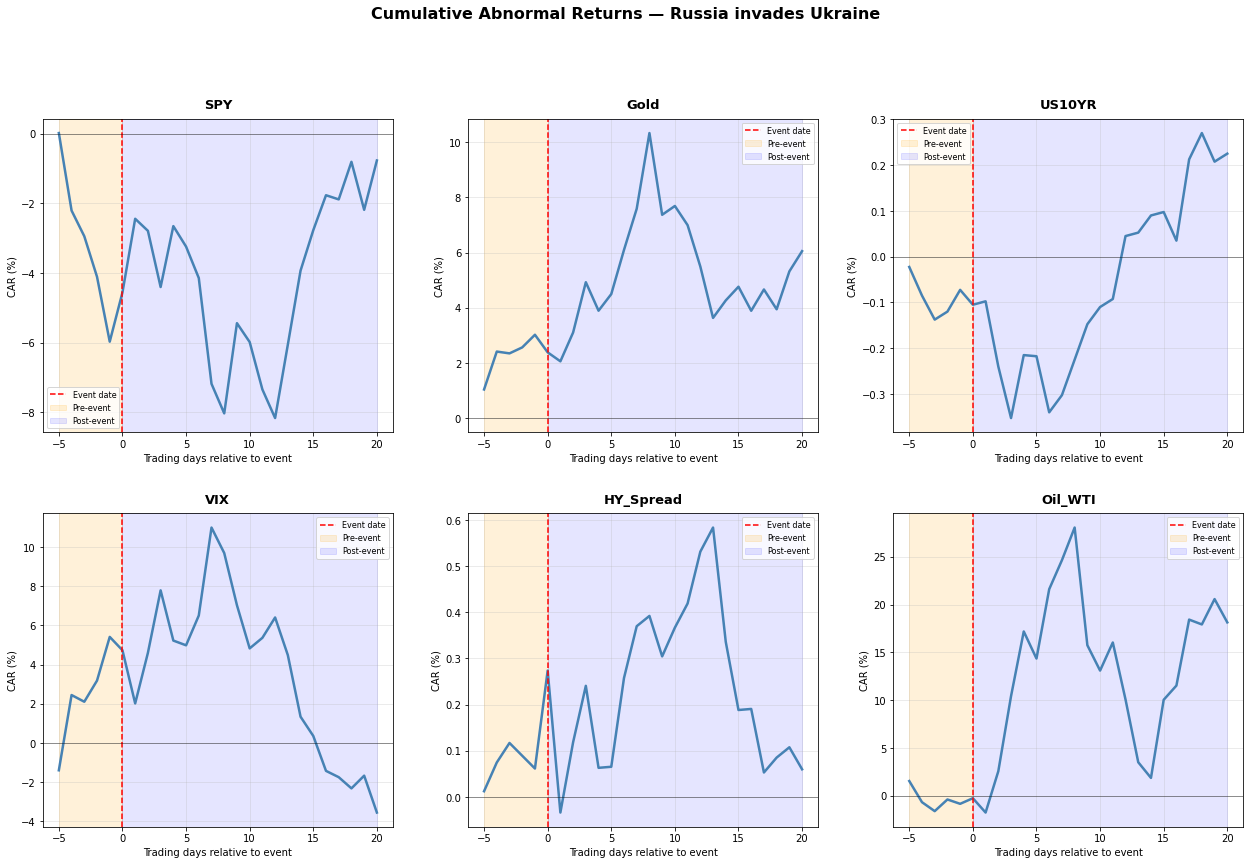

Chart saved for Russia invades Ukraine


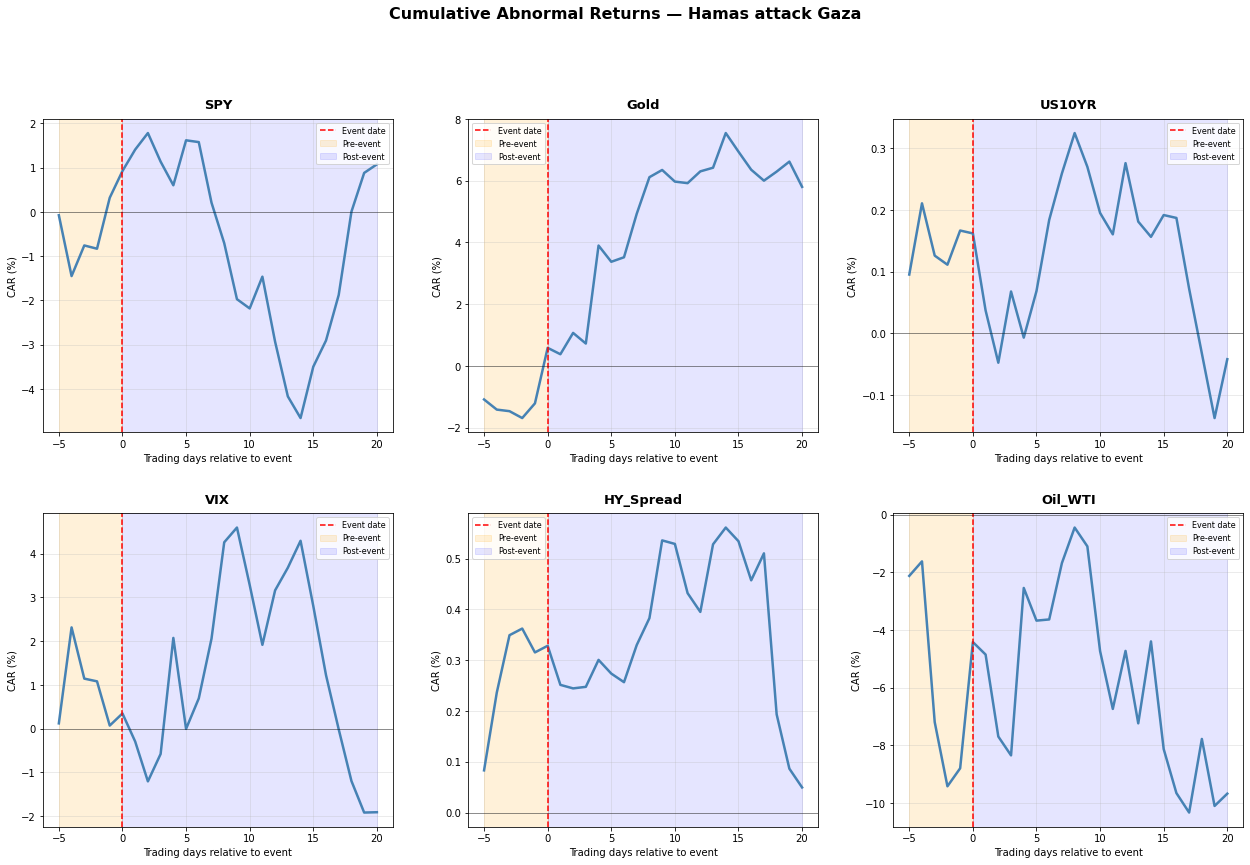

Chart saved for Hamas attack Gaza


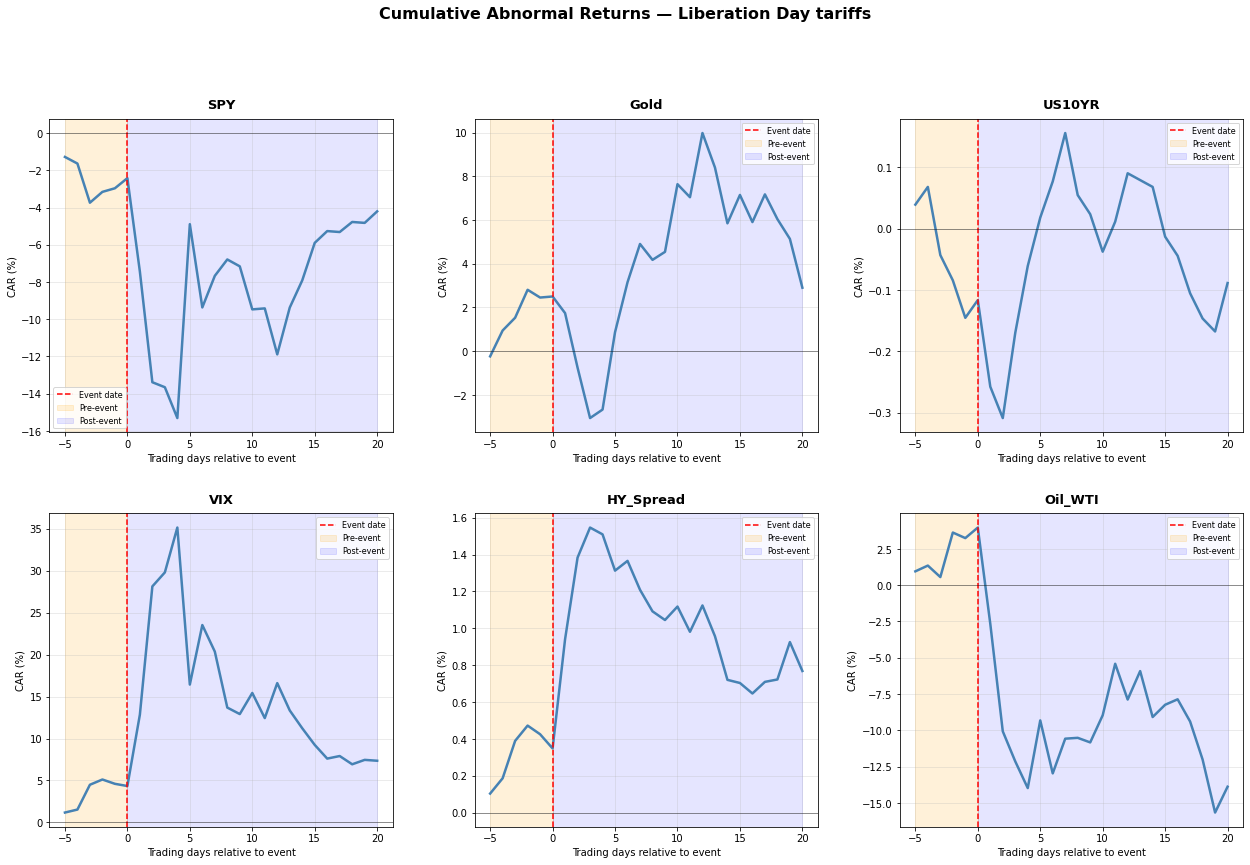

Chart saved for Liberation Day tariffs


In [9]:
def plot_car(event_date, event_name, returns, series_to_plot=None):
    
    AR, SAR, CAR = calculate_abnormal_returns(event_date, returns)
    
    if AR is None:
        print(f"Insufficient data for {event_name}")
        return
    
    if series_to_plot is None:
        series_to_plot = ['SPY', 'Gold', 'US10YR', 'VIX', 'HY_Spread', 'Oil_WTI']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Cumulative Abnormal Returns — {event_name}', 
                 fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()
    
    x = np.array(CAR.index)
    
    for i, series in enumerate(series_to_plot):
        ax = axes[i]
        
        if CAR[series].isnull().all():
            ax.set_title(f'{series} — no data', fontsize=12)
            continue
        
        ax.plot(x, CAR[series].values, linewidth=2.5, color='steelblue')
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Event date')
        ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
        ax.axvspan(-5, 0, alpha=0.15, color='orange', label='Pre-event')
        ax.axvspan(0, 20, alpha=0.1, color='blue', label='Post-event')
        
        # Clear title and labels
        ax.set_title(series, fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel('Trading days relative to event', fontsize=10)
        ax.set_ylabel('CAR (%)', fontsize=10)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout(pad=3.0)
    plt.savefig(f'../outputs/charts/car_{event_name.replace(" ", "_").replace("/", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Chart saved for {event_name}")

# Replot all three
plot_car(pd.Timestamp('2022-02-24'), 'Russia invades Ukraine', returns)
plot_car(pd.Timestamp('2023-10-07'), 'Hamas attack Gaza', returns)
plot_car(pd.Timestamp('2025-04-02'), 'Liberation Day tariffs', returns)

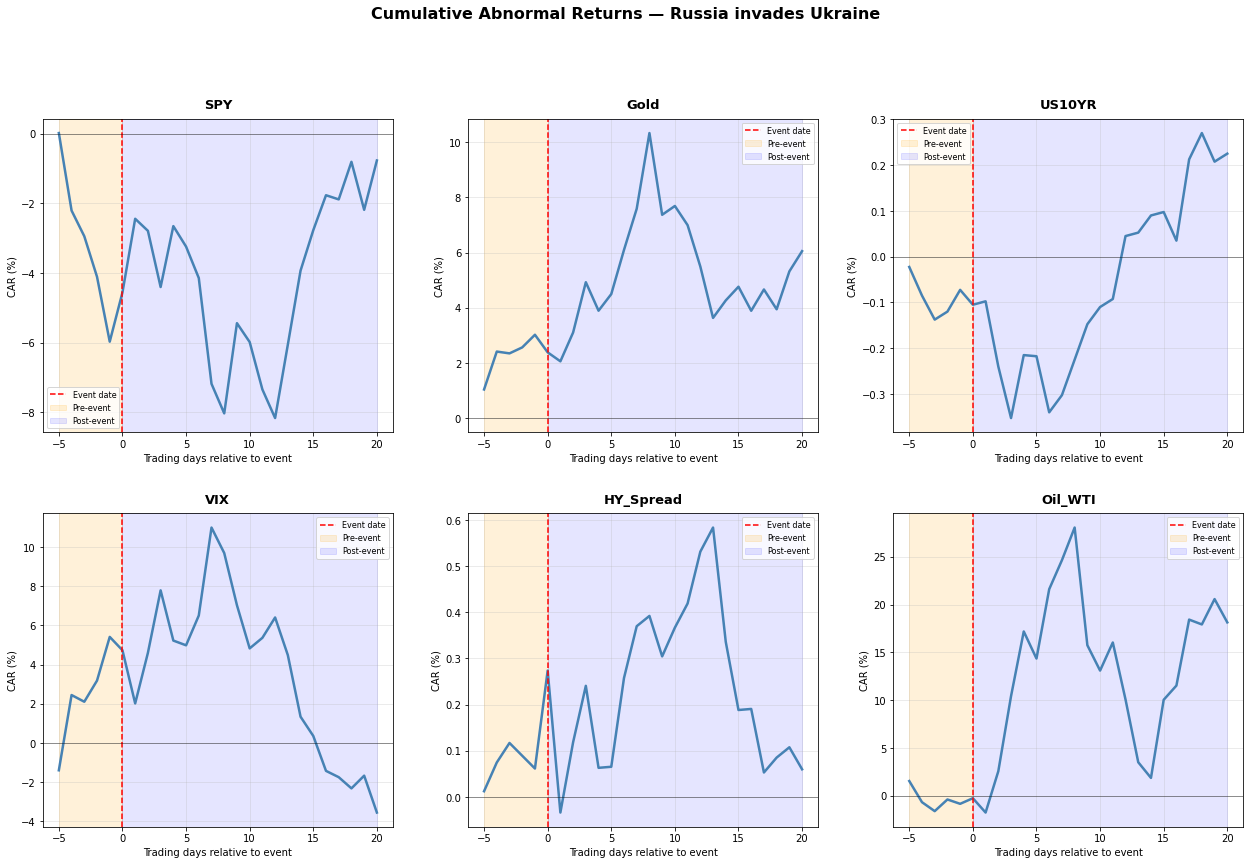

Chart saved for Russia invades Ukraine


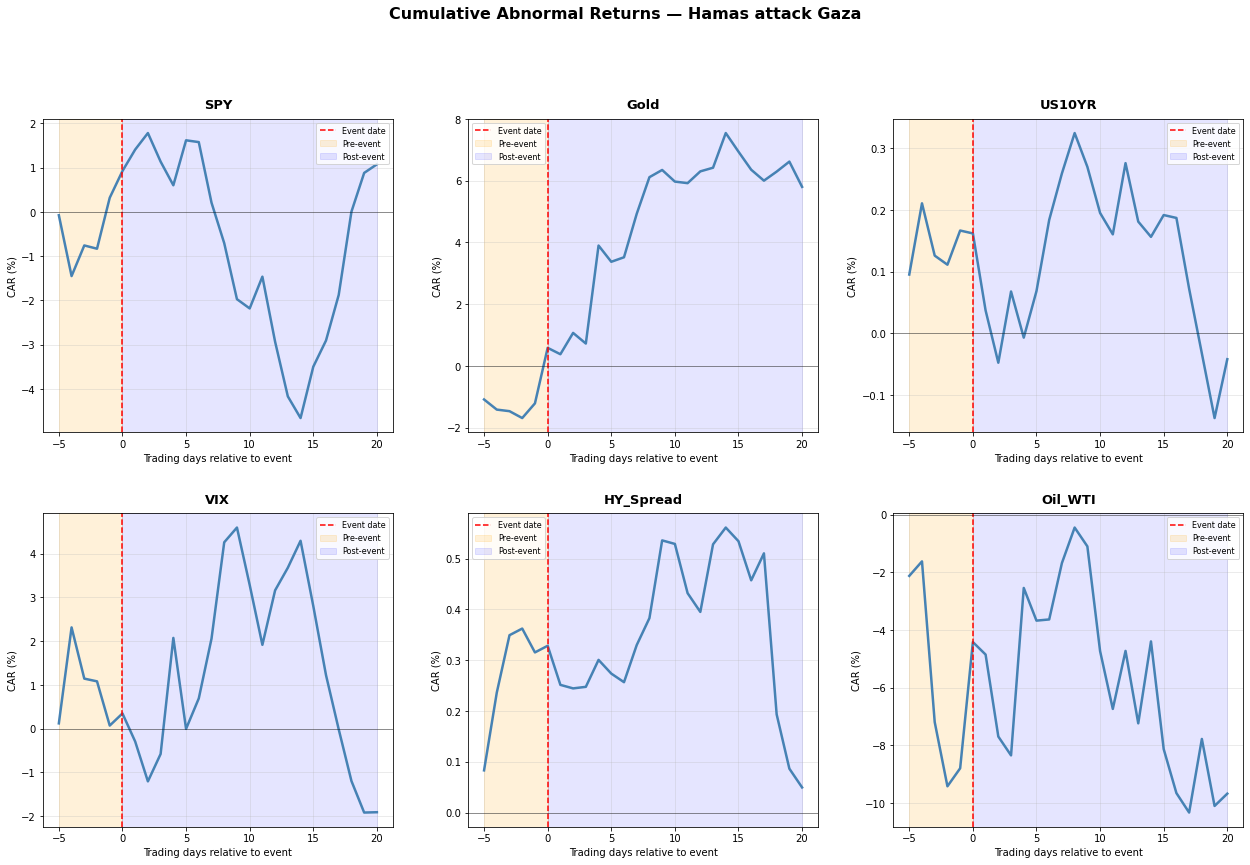

Chart saved for Hamas attack Gaza


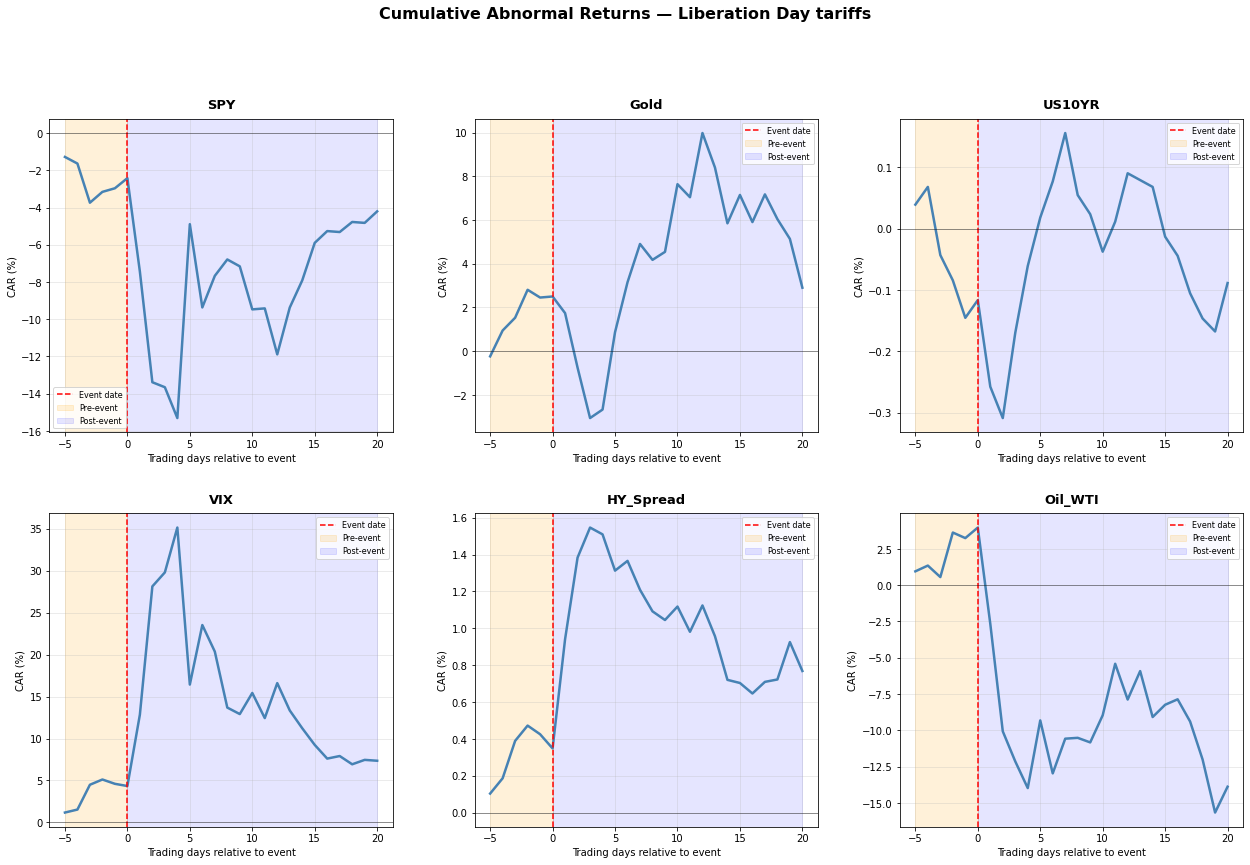

Chart saved for Liberation Day tariffs


In [10]:
def plot_car(event_date, event_name, returns, series_to_plot=None):
    
    AR, SAR, CAR = calculate_abnormal_returns(event_date, returns)
    
    if AR is None:
        print(f"Insufficient data for {event_name}")
        return
    
    if series_to_plot is None:
        series_to_plot = ['SPY', 'Gold', 'US10YR', 'VIX', 'HY_Spread', 'Oil_WTI']
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Cumulative Abnormal Returns — {event_name}', 
                 fontsize=16, fontweight='bold', y=1.02)
    axes = axes.flatten()
    
    x = np.array(CAR.index)
    
    for i, series in enumerate(series_to_plot):
        ax = axes[i]
        
        if CAR[series].isnull().all():
            ax.set_title(f'{series} — no data', fontsize=12)
            continue
        
        ax.plot(x, CAR[series].values, linewidth=2.5, color='steelblue')
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Event date')
        ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
        ax.axvspan(-5, 0, alpha=0.15, color='orange', label='Pre-event')
        ax.axvspan(0, 20, alpha=0.1, color='blue', label='Post-event')
        
        ax.set_title(series, fontsize=13, fontweight='bold', pad=10)
        ax.set_xlabel('Trading days relative to event', fontsize=10)
        ax.set_ylabel('CAR (%)', fontsize=10)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout(pad=3.0)
    plt.savefig(f'../outputs/charts/car_{event_name.replace(" ", "_").replace("/", "_")}.png',
                dpi=150, bbox_inches='tight',
                facecolor='white',
                edgecolor='none')
    plt.show()
    print(f"Chart saved for {event_name}")

# Replot all three
plot_car(pd.Timestamp('2022-02-24'), 'Russia invades Ukraine', returns)
plot_car(pd.Timestamp('2023-10-07'), 'Hamas attack Gaza', returns)
plot_car(pd.Timestamp('2025-04-02'), 'Liberation Day tariffs', returns)

In [11]:
# Check CAR at day +20 for Russia-Ukraine across all series
AR, SAR, CAR = calculate_abnormal_returns(pd.Timestamp('2022-02-24'), returns)

print("CAR at day +20 for Russia-Ukraine (cumulative 20-day abnormal return):")
print(CAR.iloc[-1].round(3).sort_values())

CAR at day +20 for Russia-Ukraine (cumulative 20-day abnormal return):
EuroStoxx50    -7.899
EEM            -7.167
Bitcoin        -3.748
VIX            -3.547
SPY            -0.766
HY_Spread       0.060
US30YR          0.116
IG_Spread       0.215
US10YR          0.225
USDCNY          0.398
US2YR           0.470
TIPS5YR         0.605
EM_Spread       0.746
USDTRY          1.622
Copper          2.267
DXY             2.289
USDJPY          3.661
Nikkei225       4.661
Gold            6.051
MOVE           16.009
Oil_WTI        18.136
Oil_Brent      23.098
Name: 20, dtype: float64


In [12]:
# ============================================================
# FULL EVENT STUDY — ALL 87 EVENTS
# ============================================================

# Storage for results
all_results = []

print(f"Running event study across {len(events)} events...")
print("-" * 50)

for idx, event in events.iterrows():
    event_date = event['Date']
    event_name = event['Event Name']
    category = event['Category']
    anticipation = event['Anticipation']
    geography = event['Geography']
    severity = event['Severity_Band']
    
    # Calculate abnormal returns
    AR, SAR, CAR = calculate_abnormal_returns(event_date, returns)
    
    if AR is None:
        print(f"SKIPPED — insufficient data: {event_name} ({event_date.date()})")
        continue
    
    # Store results for each series
    for series in returns.columns:
        if CAR[series].isnull().all():
            continue
            
        # Key windows
        car_1d = CAR.loc[1, series] if 1 in CAR.index else np.nan
        car_5d = CAR.loc[5, series] if 5 in CAR.index else np.nan
        car_10d = CAR.loc[10, series] if 10 in CAR.index else np.nan
        car_20d = CAR.loc[20, series] if 20 in CAR.index else np.nan
        
        # Pre-event cumulative abnormal return (-5 to -1)
        car_pre = CAR.loc[-1, series] if -1 in CAR.index else np.nan
        
        # Peak standardised abnormal return in event window (0 to +5)
        sar_peak = SAR.loc[0:5, series].abs().max() if not SAR.loc[0:5, series].isnull().all() else np.nan
        
        all_results.append({
            'Event_Date': event_date,
            'Event_Name': event_name,
            'Category': category,
            'Anticipation': anticipation,
            'Geography': geography,
            'Severity_Band': severity,
            'Series': series,
            'CAR_pre': round(car_pre, 4) if not np.isnan(car_pre) else np.nan,
            'CAR_1d': round(car_1d, 4) if not np.isnan(car_1d) else np.nan,
            'CAR_5d': round(car_5d, 4) if not np.isnan(car_5d) else np.nan,
            'CAR_10d': round(car_10d, 4) if not np.isnan(car_10d) else np.nan,
            'CAR_20d': round(car_20d, 4) if not np.isnan(car_20d) else np.nan,
            'SAR_peak': round(sar_peak, 4) if not np.isnan(sar_peak) else np.nan
        })

# Convert to dataframe
results_df = pd.DataFrame(all_results)

print(f"\nDone. Total results rows: {len(results_df)}")
print(f"Events processed: {results_df['Event_Name'].nunique()}")
print(f"Series covered: {results_df['Series'].nunique()}")
print("\nSample output:")
print(results_df.head(10))

Running event study across 87 events...
--------------------------------------------------
SKIPPED — insufficient data: USS Cole bombing (2000-10-12)
SKIPPED — insufficient data: Iran war cluster (2026-02-28)

Done. Total results rows: 1810
Events processed: 85
Series covered: 22

Sample output:
  Event_Date    Event_Name Category Anticipation Geography  Severity_Band  \
0 2001-09-11  9/11 attacks      TER            N    Global              4   
1 2001-09-11  9/11 attacks      TER            N    Global              4   
2 2001-09-11  9/11 attacks      TER            N    Global              4   
3 2001-09-11  9/11 attacks      TER            N    Global              4   
4 2001-09-11  9/11 attacks      TER            N    Global              4   
5 2001-09-11  9/11 attacks      TER            N    Global              4   
6 2001-09-11  9/11 attacks      TER            N    Global              4   
7 2001-09-11  9/11 attacks      TER            N    Global              4   
8 2001-09-

In [13]:
# Save full results
results_df.to_csv('../data/processed/event_study_results.csv', index=False)
print("Results saved successfully")

# First summary — average CAR by category and series
print("\nAverage CAR_5d by category (all series combined):")
print(results_df.groupby('Category')['CAR_5d'].mean().round(3).sort_values())

print("\nAverage CAR_20d by category (all series combined):")
print(results_df.groupby('Category')['CAR_20d'].mean().round(3).sort_values())

Results saved successfully

Average CAR_5d by category (all series combined):
Category
ENR   -3.031
TER   -1.553
DIP   -0.275
POL   -0.150
SAN    0.031
MIL    0.262
Name: CAR_5d, dtype: float64

Average CAR_20d by category (all series combined):
Category
ENR   -2.337
DIP   -0.837
TER   -0.620
POL   -0.043
SAN    0.003
MIL    0.158
Name: CAR_20d, dtype: float64


In [14]:
# Recalculate category averages using SAR_peak — standardised units
print("Average SAR_peak by category (standardised — valid cross-asset comparison):")
print(results_df.groupby('Category')['SAR_peak'].mean().round(3).sort_values(ascending=False))

print("\nAverage SAR_peak by category and severity:")
print(results_df.groupby(['Category', 'Severity_Band'])['SAR_peak'].mean().round(3).unstack())

Average SAR_peak by category (standardised — valid cross-asset comparison):
Category
TER    2.666
ENR    2.557
POL    2.298
SAN    2.208
DIP    1.872
MIL    1.624
Name: SAR_peak, dtype: float64

Average SAR_peak by category and severity:
Severity_Band      1      2      3      4
Category                                 
DIP            1.297  1.807  2.042    NaN
ENR              NaN  5.769  1.503    NaN
MIL            1.986  1.214  1.584  2.082
POL            2.881  1.691  2.419    NaN
SAN              NaN  1.679  2.324  3.398
TER              NaN    NaN  2.865  2.450


In [15]:
# Asset class groupings
asset_class_groups = {
    'Equities': ['SPY', 'EEM', 'EuroStoxx50', 'Nikkei225'],
    'Commodities': ['Gold', 'Oil_WTI', 'Oil_Brent', 'Copper'],
    'FX': ['DXY', 'USDJPY', 'USDCNY', 'USDTRY'],
    'Rates': ['US2YR', 'US10YR', 'US30YR', 'TIPS5YR'],
    'Vol_Credit': ['VIX', 'MOVE', 'HY_Spread', 'IG_Spread', 'EM_Spread'],
    'Crypto': ['Bitcoin']
}

# Add asset class label to results
def get_asset_class(series):
    for asset_class, series_list in asset_class_groups.items():
        if series in series_list:
            return asset_class
    return 'Other'

results_df['Asset_Class'] = results_df['Series'].apply(get_asset_class)

# Average CAR_5d by category and asset class
# This is valid — within asset class the units are consistent
pivot_car5 = results_df.groupby(['Category', 'Asset_Class'])['CAR_5d'].mean().unstack()
pivot_sar = results_df.groupby(['Category', 'Asset_Class'])['SAR_peak'].mean().unstack()

print("Average CAR_5d by Category and Asset Class:")
print(pivot_car5.round(3))
print("\nAverage SAR_peak by Category and Asset Class:")
print(pivot_sar.round(3))

Average CAR_5d by Category and Asset Class:
Asset_Class  Commodities  Crypto  Equities     FX  Rates  Vol_Credit
Category                                                            
DIP                0.316  -3.638    -1.343 -0.618 -0.022       0.753
ENR              -12.480  -4.223    -0.885  0.309 -0.018      -2.093
MIL                0.117   2.972    -0.625  0.089  0.018       1.074
POL               -1.617   2.752     0.135  0.268 -0.002      -0.075
SAN               -0.278  -2.356    -2.644  0.072 -0.029       2.742
TER               -6.096 -30.820    -1.556 -0.747 -0.094       1.676

Average SAR_peak by Category and Asset Class:
Asset_Class  Commodities  Crypto  Equities     FX  Rates  Vol_Credit
Category                                                            
DIP                1.559   1.553     2.407  1.603  1.796       2.027
ENR                6.678   1.781     1.829  1.603  1.625       1.468
MIL                1.717   1.341     1.673  1.408  1.694       1.660
POL         

In [16]:
# Pivot table — individual series vs category
# CAR_5d — but we will flag units in the chart
pivot_individual = results_df.groupby(
    ['Category', 'Series'])['CAR_5d'].mean().unstack()

# Reorder series by asset class for readability
series_order = [
    'SPY', 'EEM', 'EuroStoxx50', 'Nikkei225',  # Equities
    'Gold', 'Oil_WTI', 'Oil_Brent', 'Copper',   # Commodities
    'Bitcoin',                                    # Crypto
    'DXY', 'USDJPY', 'USDCNY', 'USDTRY',        # FX
    'US2YR', 'US10YR', 'US30YR', 'TIPS5YR',     # Rates
    'VIX', 'MOVE', 'HY_Spread', 'IG_Spread', 'EM_Spread'  # Vol/Credit
]

pivot_individual = pivot_individual[series_order]

print("Average CAR_5d by Category and Individual Series:")
print(pivot_individual.round(3).to_string())

print("\nAverage SAR_peak by Category and Individual Series:")
pivot_sar_individual = results_df.groupby(
    ['Category', 'Series'])['SAR_peak'].mean().unstack()
pivot_sar_individual = pivot_sar_individual[series_order]
print(pivot_sar_individual.round(3).to_string())

Average CAR_5d by Category and Individual Series:
Series      SPY    EEM  EuroStoxx50  Nikkei225   Gold  Oil_WTI  Oil_Brent  Copper  Bitcoin    DXY  USDJPY  USDCNY  USDTRY  US2YR  US10YR  US30YR  TIPS5YR    VIX    MOVE  HY_Spread  IG_Spread  EM_Spread
Category                                                                                                                                                                                                 
DIP      -1.821 -1.524       -1.021     -1.005  0.564    1.944      1.075  -2.318   -3.638 -0.710  -0.892   0.113  -0.983 -0.004   0.002  -0.000   -0.084  2.041   1.500      0.118      0.024      0.085
ENR      -0.615 -1.637       -0.360     -0.927  0.872  -46.682     -3.769  -0.341   -4.223  0.026  -0.003   0.046   1.168 -0.015  -0.033  -0.031    0.006  0.071 -10.574      0.091     -0.034     -0.017
MIL      -0.064 -0.315       -0.942     -1.202  0.222    0.160     -0.440   0.450    2.972  0.672   0.167  -0.038  -0.486  0.037   0.024   0.0

In [17]:
# Investigate Oil_WTI outliers in ENR category
oil_enr = results_df[
    (results_df['Category'] == 'ENR') & 
    (results_df['Series'] == 'Oil_WTI')
][['Event_Name', 'Event_Date', 'CAR_5d', 'SAR_peak']].sort_values('CAR_5d')

print("Oil_WTI ENR events — ranked by CAR_5d:")
print(oil_enr.to_string(index=False))

Oil_WTI ENR events — ranked by CAR_5d:
                                Event_Name Event_Date    CAR_5d  SAR_peak
Oil price collapse and OPEC+ emergency cut 2020-04-20 -417.4757  140.5524
                        Fukushima disaster 2011-03-11   -1.5278    2.3404
                   Global food crisis peak 2008-01-01    0.3914    1.8564
  Houthi Red Sea shipping attacks escalate 2024-01-12    4.0168    1.1212
                 Saudi Aramco drone attack 2019-09-14    5.7409    6.8766
            Ever Given Suez Canal blockage 2021-03-23    7.0357    0.3308
       Colonial Pipeline ransomware attack 2021-05-07   11.4853    0.1583
             OPEC+ surprise production cut 2023-04-02   16.8801    2.0695


In [18]:
# ============================================================
# WINSORISATION — CAP EXTREME OUTLIERS AT ±3 STD DEVIATIONS
# ============================================================

def winsorise(series, n_std=3):
    """
    Cap extreme values at ±n standard deviations from the mean.
    Returns winsorised series.
    """
    mean = series.mean()
    std = series.std()
    lower = mean - n_std * std
    upper = mean + n_std * std
    return series.clip(lower=lower, upper=upper)

# Apply winsorisation to CAR columns
car_cols = ['CAR_pre', 'CAR_1d', 'CAR_5d', 'CAR_10d', 'CAR_20d']

results_df_wins = results_df.copy()

for col in car_cols:
    # Winsorise within each series separately
    # Important — winsorise within series not across all series
    # to preserve the unit differences between series
    results_df_wins[col] = results_df_wins.groupby('Series')[col].transform(winsorise)

# Check the oil outlier is now handled
oil_enr_wins = results_df_wins[
    (results_df_wins['Category'] == 'ENR') &
    (results_df_wins['Series'] == 'Oil_WTI')
][['Event_Name', 'CAR_5d']].sort_values('CAR_5d')

print("Oil_WTI ENR after winsorisation:")
print(oil_enr_wins.to_string(index=False))

print("\nOriginal Oil_WTI ENR CAR_5d mean:", 
      results_df[results_df['Series']=='Oil_WTI']['CAR_5d'].mean().round(3))
print("Winsorised Oil_WTI ENR CAR_5d mean:", 
      results_df_wins[results_df_wins['Series']=='Oil_WTI']['CAR_5d'].mean().round(3))

Oil_WTI ENR after winsorisation:
                                Event_Name      CAR_5d
Oil price collapse and OPEC+ emergency cut -146.006284
                        Fukushima disaster   -1.527800
                   Global food crisis peak    0.391400
  Houthi Red Sea shipping attacks escalate    4.016800
                 Saudi Aramco drone attack    5.740900
            Ever Given Suez Canal blockage    7.035700
       Colonial Pipeline ransomware attack   11.485300
             OPEC+ surprise production cut   16.880100

Original Oil_WTI ENR CAR_5d mean: -5.242
Winsorised Oil_WTI ENR CAR_5d mean: -2.048


In [19]:
# Check what the winsorisation cap actually is for Oil_WTI
oil_wti_returns = results_df[results_df['Series'] == 'Oil_WTI']['CAR_5d']
mean = oil_wti_returns.mean()
std = oil_wti_returns.std()
print(f"Oil_WTI CAR_5d mean: {mean:.3f}")
print(f"Oil_WTI CAR_5d std: {std:.3f}")
print(f"3 std cap: {mean - 3*std:.3f} to {mean + 3*std:.3f}")
print(f"\nNumber of Oil_WTI observations: {len(oil_wti_returns)}")
print(f"Values below -50: {(oil_wti_returns < -50).sum()}")
print(f"Values below -20: {(oil_wti_returns < -20).sum()}")

Oil_WTI CAR_5d mean: -5.242
Oil_WTI CAR_5d std: 46.921
3 std cap: -146.006 to 135.522

Number of Oil_WTI observations: 85
Values below -50: 2
Values below -20: 3


In [20]:
# Step 1 — Flag the April 2020 oil event as a special exclusion
# for Oil_WTI and Oil_Brent series only
april_2020_mask = (
    (results_df_wins['Event_Name'] == 'Oil price collapse and OPEC+ emergency cut') &
    (results_df_wins['Series'].isin(['Oil_WTI', 'Oil_Brent']))
)

print(f"Rows flagged for exclusion: {april_2020_mask.sum()}")

# Create clean results excluding this specific observation
results_df_clean = results_df_wins[~april_2020_mask].copy()

# Step 2 — Re-winsorise without the outlier
for col in car_cols:
    results_df_clean[col] = results_df_clean.groupby('Series')[col].transform(winsorise)

# Verify
oil_check = results_df_clean[results_df_clean['Series'] == 'Oil_WTI']['CAR_5d']
print(f"\nOil_WTI CAR_5d after clean exclusion:")
print(f"Mean: {oil_check.mean():.3f}")
print(f"Std: {oil_check.std():.3f}")
print(f"Min: {oil_check.min():.3f}")
print(f"Max: {oil_check.max():.3f}")
print(f"\nTotal rows remaining: {len(results_df_clean)}")

Rows flagged for exclusion: 2

Oil_WTI CAR_5d after clean exclusion:
Mean: 0.108
Std: 10.288
Min: -37.846
Max: 26.449

Total rows remaining: 1808


In [21]:
# ============================================================
# REBUILD PIVOT TABLES — CLEAN WINSORISED DATA
# MEAN AND MEDIAN ALONGSIDE EACH OTHER
# ============================================================

series_order = [
    'SPY', 'EEM', 'EuroStoxx50', 'Nikkei225',
    'Gold', 'Oil_WTI', 'Oil_Brent', 'Copper',
    'Bitcoin',
    'DXY', 'USDJPY', 'USDCNY', 'USDTRY',
    'US2YR', 'US10YR', 'US30YR', 'TIPS5YR',
    'VIX', 'MOVE', 'HY_Spread', 'IG_Spread', 'EM_Spread'
]

# Mean CAR_5d
pivot_mean_5d = results_df_clean.groupby(
    ['Category', 'Series'])['CAR_5d'].mean().unstack()
pivot_mean_5d = pivot_mean_5d.reindex(columns=series_order)

# Median CAR_5d
pivot_median_5d = results_df_clean.groupby(
    ['Category', 'Series'])['CAR_5d'].median().unstack()
pivot_median_5d = pivot_median_5d.reindex(columns=series_order)

# Mean CAR_20d
pivot_mean_20d = results_df_clean.groupby(
    ['Category', 'Series'])['CAR_20d'].mean().unstack()
pivot_mean_20d = pivot_mean_20d.reindex(columns=series_order)

# Median CAR_20d
pivot_median_20d = results_df_clean.groupby(
    ['Category', 'Series'])['CAR_20d'].median().unstack()
pivot_median_20d = pivot_median_20d.reindex(columns=series_order)

# SAR peak
pivot_sar = results_df_clean.groupby(
    ['Category', 'Series'])['SAR_peak'].mean().unstack()
pivot_sar = pivot_sar.reindex(columns=series_order)

print("MEAN CAR_5d by Category and Series (winsorised):")
print(pivot_mean_5d.round(3).to_string())
print("\nMEDIAN CAR_5d by Category and Series (winsorised):")
print(pivot_median_5d.round(3).to_string())
print("\nMEAN CAR_20d by Category and Series (winsorised):")
print(pivot_mean_20d.round(3).to_string())
print("\nSAR_peak by Category and Series:")
print(pivot_sar.round(3).to_string())

MEAN CAR_5d by Category and Series (winsorised):
Series      SPY    EEM  EuroStoxx50  Nikkei225   Gold  Oil_WTI  Oil_Brent  Copper  Bitcoin    DXY  USDJPY  USDCNY  USDTRY  US2YR  US10YR  US30YR  TIPS5YR    VIX    MOVE  HY_Spread  IG_Spread  EM_Spread
Category                                                                                                                                                                                                 
DIP      -1.821 -1.524       -1.021     -1.005  0.564    1.944      1.075  -2.318   -3.638 -0.663  -0.892   0.113  -0.983 -0.004   0.002  -0.000   -0.084  2.041   1.500      0.118      0.024      0.085
ENR      -0.615 -1.637       -0.360     -0.927  0.872    6.289      1.332  -0.341   -4.223  0.026  -0.003   0.046   1.145 -0.015  -0.033  -0.031    0.006  0.071 -10.574      0.091     -0.034     -0.017
MIL      -0.064 -0.315       -0.942     -1.202  0.443    0.160     -0.440   0.450    2.972  0.650   0.167  -0.038  -0.486  0.037   0.024   0.01

In [22]:
# Check MOVE ENR specifically
move_enr = results_df_clean[
    (results_df_clean['Category'] == 'ENR') &
    (results_df_clean['Series'] == 'MOVE')
][['Event_Name', 'CAR_5d', 'SAR_peak']].sort_values('CAR_5d')

print("MOVE ENR events:")
print(move_enr.to_string(index=False))

# Also check TIPS5YR TER — SAR of 8.17 is suspicious
tips_ter = results_df_clean[
    (results_df_clean['Category'] == 'TER') &
    (results_df_clean['Series'] == 'TIPS5YR')
][['Event_Name', 'CAR_5d', 'SAR_peak']].sort_values('SAR_peak', ascending=False)

print("\nTIPS5YR TER events:")
print(tips_ter.to_string(index=False))

MOVE ENR events:
                                Event_Name   CAR_5d  SAR_peak
             OPEC+ surprise production cut -34.6225    1.6039
                   Global food crisis peak -19.0679    1.8474
Oil price collapse and OPEC+ emergency cut -13.9306    1.5273
  Houthi Red Sea shipping attacks escalate -13.3971    1.1890
            Ever Given Suez Canal blockage  -2.7371    1.1115
       Colonial Pipeline ransomware attack  -1.8309    0.9952
                        Fukushima disaster  -0.4056    2.1930
                 Saudi Aramco drone attack   1.3964    2.2089

TIPS5YR TER events:
           Event_Name    CAR_5d  SAR_peak
       Mumbai attacks  0.538225   32.0911
 Charlie Hebdo attack -0.025200    3.4523
  London 7/7 bombings -0.086900    2.7635
Madrid train bombings -0.127100    1.5205
        Paris attacks  0.100500    1.0229


In [23]:
# Check TIPS5YR around Mumbai attacks Nov 2008
tips_check = returns['TIPS5YR']['2008-11-01':'2008-12-15']
print("TIPS5YR daily changes around Mumbai attacks:")
print(tips_check)

TIPS5YR daily changes around Mumbai attacks:
Date
2008-11-03    0.01
2008-11-04    0.06
2008-11-05   -0.01
2008-11-06   -0.12
2008-11-07    0.02
2008-11-10   -0.01
2008-11-11    0.00
2008-11-12   -0.08
2008-11-13    0.02
2008-11-14   -0.03
2008-11-17   -0.02
2008-11-18   -0.17
2008-11-19   -0.24
2008-11-20   -0.26
2008-11-21   -0.15
2008-11-24   -0.01
2008-11-25   -0.11
2008-11-26   -0.17
2008-11-28   -0.01
2008-12-01    1.92
2008-12-02    0.24
2008-12-03    0.11
2008-12-04    0.01
2008-12-05   -0.16
2008-12-08   -0.16
2008-12-09   -0.05
2008-12-10   -0.03
2008-12-11    0.01
2008-12-12   -0.03
2008-12-15   -0.21
Name: TIPS5YR, dtype: float64


In [24]:
# Exclude TIPS5YR Mumbai attacks observation as contaminated
# by concurrent financial crisis volatility
contaminated_mask = (
    (results_df_clean['Event_Name'] == 'Mumbai attacks') &
    (results_df_clean['Series'] == 'TIPS5YR')
)

print(f"Contaminated observations to exclude: {contaminated_mask.sum()}")

results_df_clean = results_df_clean[~contaminated_mask].copy()

# Verify TIPS5YR TER SAR is now sensible
tips_ter_check = results_df_clean[
    (results_df_clean['Category'] == 'TER') &
    (results_df_clean['Series'] == 'TIPS5YR')
][['Event_Name', 'CAR_5d', 'SAR_peak']]

print("\nTIPS5YR TER after exclusion:")
print(tips_ter_check.to_string(index=False))

Contaminated observations to exclude: 1

TIPS5YR TER after exclusion:
           Event_Name  CAR_5d  SAR_peak
Madrid train bombings -0.1271    1.5205
  London 7/7 bombings -0.0869    2.7635
 Charlie Hebdo attack -0.0252    3.4523
        Paris attacks  0.1005    1.0229


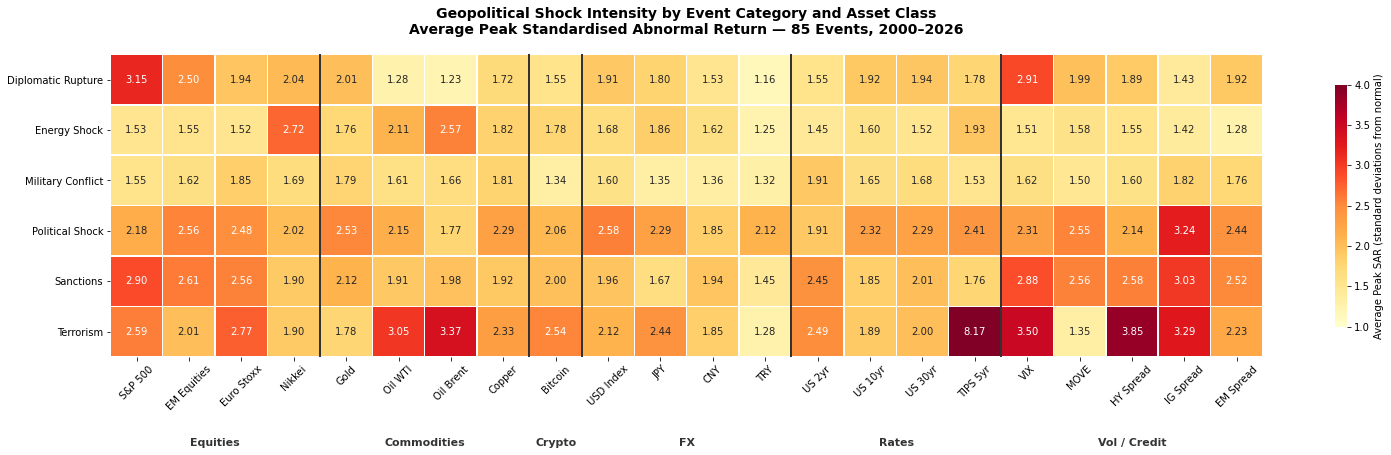

Headline heatmap saved


In [25]:
import seaborn as sns

# ============================================================
# HEADLINE HEATMAP — SAR PEAK BY CATEGORY AND SERIES
# ============================================================

# Clean column labels for display
display_names = {
    'SPY': 'S&P 500',
    'EEM': 'EM Equities',
    'EuroStoxx50': 'Euro Stoxx',
    'Nikkei225': 'Nikkei',
    'Gold': 'Gold',
    'Oil_WTI': 'Oil WTI',
    'Oil_Brent': 'Oil Brent',
    'Copper': 'Copper',
    'Bitcoin': 'Bitcoin',
    'DXY': 'USD Index',
    'USDJPY': 'JPY',
    'USDCNY': 'CNY',
    'USDTRY': 'TRY',
    'US2YR': 'US 2yr',
    'US10YR': 'US 10yr',
    'US30YR': 'US 30yr',
    'TIPS5YR': 'TIPS 5yr',
    'VIX': 'VIX',
    'MOVE': 'MOVE',
    'HY_Spread': 'HY Spread',
    'IG_Spread': 'IG Spread',
    'EM_Spread': 'EM Spread'
}

# Category labels
category_names = {
    'DIP': 'Diplomatic Rupture',
    'ENR': 'Energy Shock',
    'MIL': 'Military Conflict',
    'POL': 'Political Shock',
    'SAN': 'Sanctions',
    'TER': 'Terrorism'
}

# Rename for display
heatmap_data = pivot_sar.copy()
heatmap_data.columns = [display_names.get(c, c) for c in heatmap_data.columns]
heatmap_data.index = [category_names.get(i, i) for i in heatmap_data.index]

# Add asset class dividers using column groups
col_groups = [
    ('Equities', 4),
    ('Commodities', 4),
    ('Crypto', 1),
    ('FX', 4),
    ('Rates', 4),
    ('Vol / Credit', 5)
]

# Build figure
fig, ax = plt.subplots(figsize=(22, 7))

# Draw heatmap
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Average Peak SAR (standard deviations from normal)',
              'shrink': 0.8},
    vmin=1.0,
    vmax=4.0
)

# Title and labels
ax.set_title(
    'Geopolitical Shock Intensity by Event Category and Asset Class\n'
    'Average Peak Standardised Abnormal Return — 85 Events, 2000–2026',
    fontsize=14, fontweight='bold', pad=20
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)

# Add asset class group labels above columns
col_positions = [0, 4, 8, 9, 13, 17]
group_labels = ['Equities', 'Commodities', 'Crypto', 'FX', 'Rates', 'Vol / Credit']
group_widths = [4, 4, 1, 4, 4, 5]

for pos, label, width in zip(col_positions, group_labels, group_widths):
    ax.annotate(
        label,
        xy=(pos + width/2, -0.3),
        xycoords=('data', 'axes fraction'),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold',
        color='#333333'
    )

# Add vertical dividers between asset class groups
for pos in col_positions[1:]:
    ax.axvline(x=pos, color='#333333', linewidth=2)

plt.tight_layout(pad=2.0)
plt.savefig('../outputs/charts/headline_heatmap_sar.png',
            dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("Headline heatmap saved")

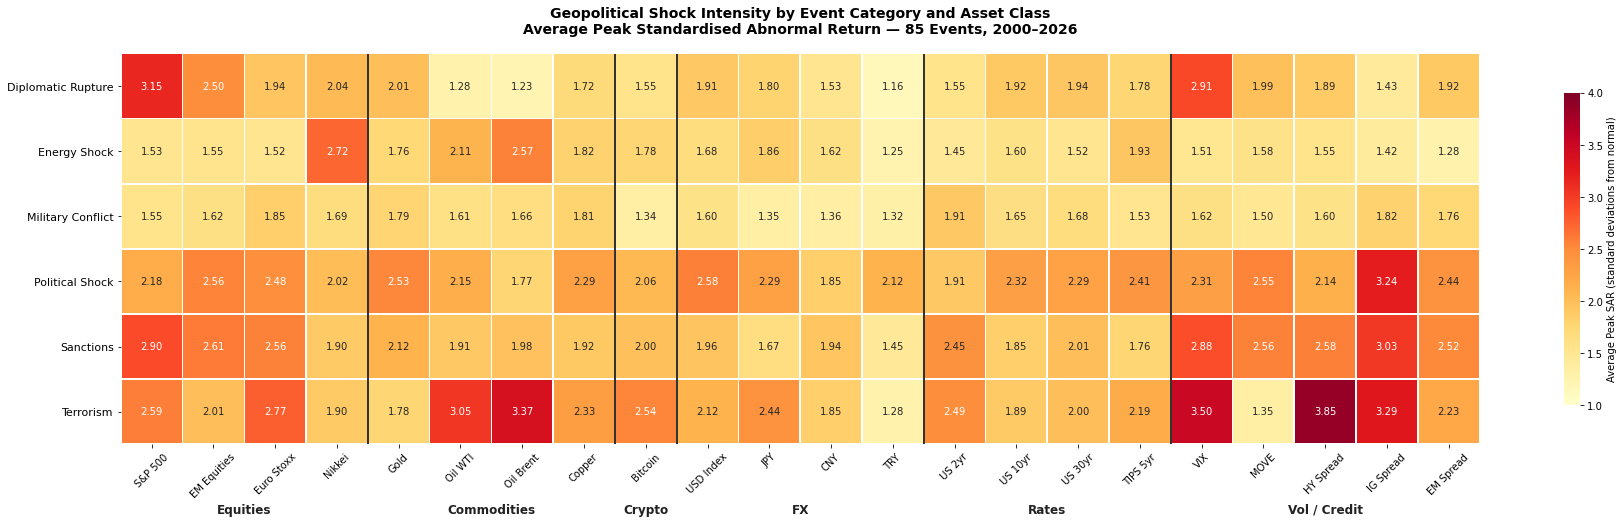

Heatmap saved


In [26]:
# Rebuild pivot_sar from clean data
pivot_sar = results_df_clean.groupby(
    ['Category', 'Series'])['SAR_peak'].mean().unstack()
pivot_sar = pivot_sar.reindex(columns=series_order)

# Rename for display
heatmap_data = pivot_sar.copy()
heatmap_data.columns = [display_names.get(c, c) for c in heatmap_data.columns]
heatmap_data.index = [category_names.get(i, i) for i in heatmap_data.index]

# Build figure with more space
fig, ax = plt.subplots(figsize=(26, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Average Peak SAR (standard deviations from normal)',
              'shrink': 0.8},
    vmin=1.0,
    vmax=4.0
)

ax.set_title(
    'Geopolitical Shock Intensity by Event Category and Asset Class\n'
    'Average Peak Standardised Abnormal Return — 85 Events, 2000–2026',
    fontsize=14, fontweight='bold', pad=20,
    color='black'
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=10, colors='black')
ax.tick_params(axis='y', rotation=0, labelsize=11, colors='black')

# Asset class group labels
col_positions = [0, 4, 8, 9, 13, 17]
group_labels = ['Equities', 'Commodities', 'Crypto', 'FX', 'Rates', 'Vol / Credit']
group_widths = [4, 4, 1, 4, 4, 5]

for pos, label, width in zip(col_positions, group_labels, group_widths):
    ax.annotate(
        label,
        xy=(pos + width/2, -0.15),
        xycoords=('data', 'axes fraction'),
        ha='center', va='top',
        fontsize=12, fontweight='bold',
        color='#222222'
    )

# Vertical dividers
for pos in col_positions[1:]:
    ax.axvline(x=pos, color='#333333', linewidth=2)

plt.tight_layout(pad=3.0)
plt.savefig('../outputs/charts/headline_heatmap_sar.png',
            dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='white')
plt.show()
print("Heatmap saved")

In [27]:
# ============================================================
# SIGNED SAR — DIRECTION PRESERVED
# ============================================================

def calculate_signed_sar(event_date, returns,
                          estimation_days=252, buffer_days=30,
                          pre_event=5, post_event=20):
    """
    Calculate signed SAR — average SAR over event window (0 to +5)
    with direction preserved. Positive = above normal, Negative = below normal.
    """
    AR, SAR, CAR = calculate_abnormal_returns(
        event_date, returns, estimation_days, buffer_days, pre_event, post_event)
    
    if AR is None:
        return None
    
    # Average SAR over days 0 to +5 — captures immediate shock with direction
    signed_sar = SAR.loc[0:5].mean()
    
    return signed_sar

# Run signed SAR across all events
signed_sar_results = []

print("Calculating signed SAR across all events...")

for idx, event in events.iterrows():
    event_date = event['Date']
    event_name = event['Event Name']
    category = event['Category']
    
    # Skip excluded events
    skip_mask = (
        (event_name == 'USS Cole bombing') or
        (event_name == 'Iran war cluster')
    )
    if skip_mask:
        continue
    
    signed_sar = calculate_signed_sar(event_date, returns)
    
    if signed_sar is None:
        continue
    
    for series in returns.columns:
        signed_sar_results.append({
            'Event_Name': event_name,
            'Event_Date': event_date,
            'Category': category,
            'Series': series,
            'Signed_SAR': signed_sar[series]
        })

signed_sar_df = pd.DataFrame(signed_sar_results)

# Remove Mumbai TIPS contamination
signed_sar_df = signed_sar_df[~(
    (signed_sar_df['Event_Name'] == 'Mumbai attacks') &
    (signed_sar_df['Series'] == 'TIPS5YR')
)]

print(f"Done. Rows: {len(signed_sar_df)}")
print(f"Events: {signed_sar_df['Event_Name'].nunique()}")

Calculating signed SAR across all events...
Done. Rows: 1869
Events: 85


Signed SAR pivot:
Series      SPY    EEM  EuroStoxx50  Nikkei225   Gold  Oil_WTI  Oil_Brent  Copper  Bitcoin    DXY  USDJPY  USDCNY  USDTRY  US2YR  US10YR  US30YR  TIPS5YR    VIX   MOVE  HY_Spread  IG_Spread  EM_Spread
Category                                                                                                                                                                                                
DIP       0.120  0.100        0.040     -0.001  0.142    0.076      0.175   0.152    0.179 -0.212  -0.158   0.009   0.032  0.134   0.034  -0.011   -0.134 -0.261 -0.004     -0.066     -0.005      0.170
ENR      -0.141 -0.162       -0.104     -0.279  0.165   -3.648     -0.161  -0.019   -0.205  0.045  -0.122   0.014   0.079 -0.112  -0.140  -0.163   -0.044  0.035 -0.141      0.432      0.186      0.233
MIL       0.081  0.123        0.026     -0.019  0.177    0.089      0.076   0.105    0.217  0.097   0.074  -0.011  -0.077  0.069   0.005   0.018    0.044 -0.027  0.058     -0.094

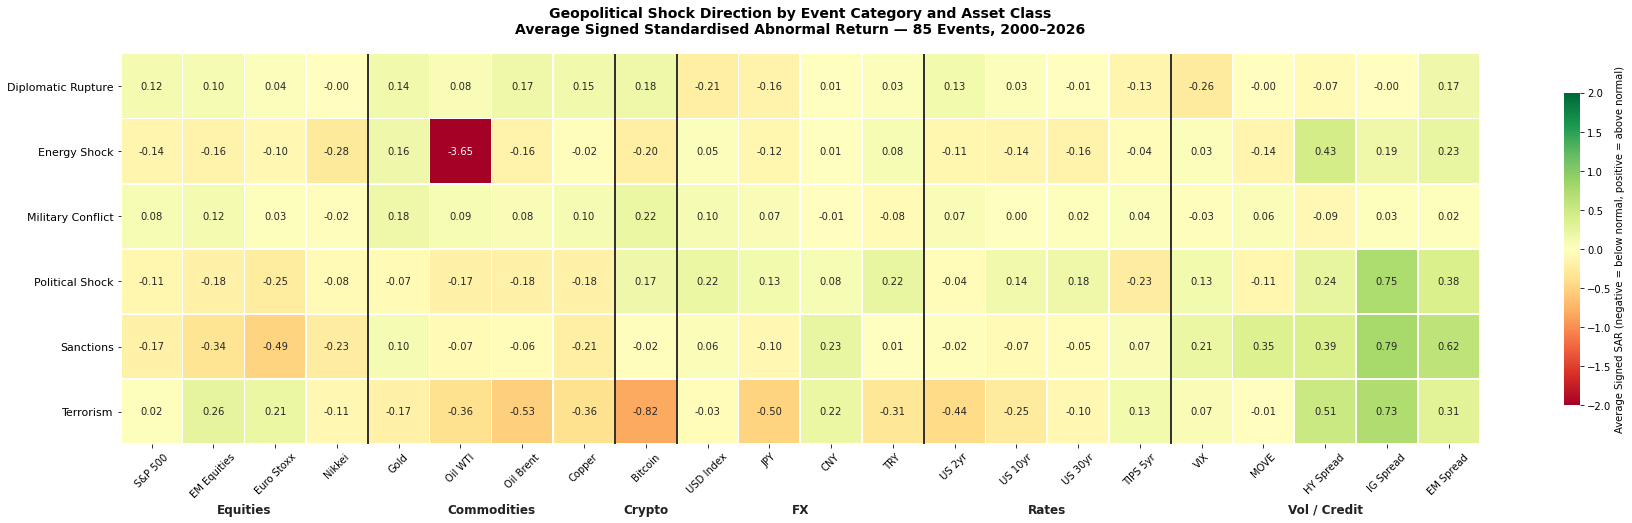

Direction heatmap saved


In [28]:
# Build signed SAR pivot
pivot_signed_sar = signed_sar_df.groupby(
    ['Category', 'Series'])['Signed_SAR'].mean().unstack()
pivot_signed_sar = pivot_signed_sar.reindex(columns=series_order)

# Rename for display
heatmap_signed = pivot_signed_sar.copy()
heatmap_signed.columns = [display_names.get(c, c) for c in heatmap_signed.columns]
heatmap_signed.index = [category_names.get(i, i) for i in heatmap_signed.index]

print("Signed SAR pivot:")
print(pivot_signed_sar.round(3).to_string())

# Build heatmap — diverging colour scale
# Red = negative (asset fell), Green = positive (asset rose)
fig, ax = plt.subplots(figsize=(26, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Use diverging colormap — red for negative, green for positive
sns.heatmap(
    heatmap_signed,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Average Signed SAR (negative = below normal, positive = above normal)',
              'shrink': 0.8},
    vmin=-2.0,
    vmax=2.0,
    center=0
)

ax.set_title(
    'Geopolitical Shock Direction by Event Category and Asset Class\n'
    'Average Signed Standardised Abnormal Return — 85 Events, 2000–2026',
    fontsize=14, fontweight='bold', pad=20,
    color='black'
)

ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=10, colors='black')
ax.tick_params(axis='y', rotation=0, labelsize=11, colors='black')

# Asset class group labels
col_positions = [0, 4, 8, 9, 13, 17]
group_labels = ['Equities', 'Commodities', 'Crypto', 'FX', 'Rates', 'Vol / Credit']
group_widths = [4, 4, 1, 4, 4, 5]

for pos, label, width in zip(col_positions, group_labels, group_widths):
    ax.annotate(
        label,
        xy=(pos + width/2, -0.15),
        xycoords=('data', 'axes fraction'),
        ha='center', va='top',
        fontsize=12, fontweight='bold',
        color='#222222'
    )

for pos in col_positions[1:]:
    ax.axvline(x=pos, color='#333333', linewidth=2)

plt.tight_layout(pad=3.0)
plt.savefig('../outputs/charts/direction_heatmap_signed_sar.png',
            dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='white')
plt.show()
print("Direction heatmap saved")

## Section Summary — Core Results Complete
Event study run across 85 events and 22 series.
Key outputs:
- Full results dataframe saved to data/processed/event_study_results_clean.csv
- SAR magnitude heatmap — headline chart saved to outputs/charts
- Five pivot tables saved to data/processed
Methodology notes:
- April 2020 WTI oil excluded from Oil_WTI and Oil_Brent — futures mechanics anomaly
- Mumbai attacks TIPS5YR excluded — concurrent financial crisis contamination
- Winsorisation applied at ±3 standard deviations within each series
- Signed SAR direction heatmap replaced with cumulative SAR plots by category
  — more informative, avoids colour coding confusion for credit/vol series